# 04 — LLM ABSA smoke test

Test sur un échantillon de 200 segments.

In [2]:
from pathlib import Path
import sys, json, warnings
warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
while not (ROOT / "config" / "project_config.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "config" / "project_config.json").exists(), "Project root not found."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

CONFIG = json.loads((ROOT / "config" / "project_config.json").read_text(encoding="utf-8"))
SEED = CONFIG["random_seed"]
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)


ROOT: C:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first


## 1. Taxonomie, prompt et client LLM

In [3]:
from src.absa_utils import load_taxonomy, core_aspect_ids, build_system_prompt
from src.llm_client import ChatCompletionsHTTPClient
from src.sampling_utils import sample_segments
from src.inference_utils import infer_dataframe

taxonomy = load_taxonomy(ROOT)
aspect_ids = core_aspect_ids(taxonomy)
prompt_version = CONFIG["llm"]["prompt_version"]
system_prompt = build_system_prompt(taxonomy, prompt_version)
client = ChatCompletionsHTTPClient.from_env(ROOT, CONFIG)
print("Model:", client.model)
print("Endpoint configured:", bool(client.endpoint_url))

Model: nvidia/nvidia-nemotron-nano-9b-v2
Endpoint configured: True


## 2. Échantillon

In [5]:
N = CONFIG["llm"]["smoke_test_segments"]
smoke = sample_segments(ROOT, n=N, seed=SEED, min_words=CONFIG["min_words_for_llm"])
print("Segments:", len(smoke))
display(smoke[["segment_id","segment_text"]].head(10))

Segments: 200


,segment_id,segment_text
0,reviews_0-250::255193::s0,10/10 recommend for dull skin or fine lines an...
1,reviews_750-1250::38940::s1,I only use it once a week (occasionally I’ll d...
2,reviews_750-1250::82280::s2,"I don’t remember to use it every single day, b..."
3,reviews_750-1250::1556::s5,It feels nourishing and moisturizingwithout be...
4,reviews_0-250::135903::s4,I would definitely recommend this if you are s...
5,reviews_0-250::152420::s5,"I must admit, it’s a bit expensive, but I know..."
6,reviews_1250-end::43994::s1,It was sily and cooling and comforting.
7,reviews_500-750::87556::s1,"If that is the case for you as well, this may ..."
8,reviews_0-250::543022::s2,"I have combination skin, so it did dry me out ..."
9,reviews_500-750::49720::s3,Definitely a night mask as it does leave some ...


## 3. Inférence

Les réponses brutes sont conservées pour inspection.

In [4]:
import os

print("ENV endpoint :", os.getenv("LLM_ENDPOINT_URL"))
print("ENV model    :", os.getenv("LLM_MODEL"))

ENV endpoint : https://integrate.api.nvidia.com/v1/chat/completions
ENV model    : nvidia/nvidia-nemotron-nano-9b-v2


In [14]:
client.model = "meta/llama-3.1-8b-instruct"

client.timeout = 60
client.max_retries = 0

print("MODEL =", client.model)
print("TIMEOUT =", client.timeout)
print("MAX_RETRIES =", client.max_retries)

test = client.annotate(
    system_prompt="You are a helpful assistant.",
    user_prompt="Reply only with OK.",
    temperature=0.0,
)

print(test)

MODEL = meta/llama-3.1-8b-instruct
TIMEOUT = 60
MAX_RETRIES = 0
LLMResponse(text='OK.', latency_seconds=2.945428999955766, input_tokens=46, output_tokens=3, status_code=200, attempts=1)


In [6]:
MODEL_RUN = "llama-3.1-8b-instruct"

OUT_DIR = ROOT / "data" / "interim" / "benchmark_200" / MODEL_RUN
RAW_DIR = OUT_DIR / "raw"

OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

assert len(smoke) == 200, f"On attend 200 segments, trouvé : {len(smoke)}"

status, pairs, requests_log = infer_dataframe(
    smoke,
    client,
    system_prompt,
    set(aspect_ids),
    batch_size=1,
    temperature=CONFIG["llm"]["temperature"],
    raw_dir=RAW_DIR,
    run_name=MODEL_RUN,
    prompt_version=prompt_version,
)

status.to_parquet(
    OUT_DIR / "status.parquet",
    index=False,
)

pairs.to_parquet(
    OUT_DIR / "pairs.parquet",
    index=False,
)

requests_log.to_csv(
    OUT_DIR / "requests.csv",
    index=False,
)

print("Model :", client.model)
print("Segments :", len(status))
print("Aspect pairs :", len(pairs))


===== NVIDIA ERROR =====
STATUS: 500
BODY: {"type":"urn:nvcf-worker-service:problem-details:internal-server-error", "title":"Internal Server Error", "status":500, "detail":"Internal error while making inference request"}
MODEL: meta/llama-3.1-8b-instruct
SYSTEM PROMPT CHARS: 2352
USER PROMPT CHARS: 103

Model : meta/llama-3.1-8b-instruct
Segments : 200
Aspect pairs : 197


In [13]:
from pathlib import Path
import pyarrow.parquet as pq

SEGMENT_DIR = ROOT / "data" / "interim" / "segment_parts"

files = sorted(SEGMENT_DIR.glob("*.parquet"))

total_segments = sum(
    pq.ParquetFile(path).metadata.num_rows
    for path in files
)

print("Fichiers :", len(files))
print("Total segments :", f"{total_segments:,}")

Fichiers : 15
Total segments : 4,314,133


In [ ]:
ventes=[{"p":"pc","prix":100},
        {"p":"tel","prix":200},
        
        {"p":"tab","prix":150},
        {"p":"pc","prix":100},
        {"p":"tel","prix":200}
]

di={}
l=[]
for i in ventes:
    for j in i.keys():
        
        l.append(i.get(j))
        #print(l)
    print(l[0],l[1])
    if l[0] in di.keys():
        di.update({l[0]:l[1]+l[1]})
        l=[]
    else:
        di.update({l[0]:l[1]})
        l=[]
    
    

print(di)



pc 100
tel 200
tab 150
pc 100
tel 200
{'pc': 200, 'tel': 400, 'tab': 150}


## 4. Contrôles automatiques

In [16]:
from src.quality_utils import automatic_quality_summary

BENCH_DIR = ROOT / "data" / "interim" / "benchmark_200"

results = {}

for model_run in ["gpt_oss_20b", "llama-3.1-8b-instruct"]:
    model_dir = BENCH_DIR / model_run

    status_model = pd.read_parquet(model_dir / "status.parquet")
    pairs_model = pd.read_parquet(model_dir / "pairs.parquet")

    quality_model = automatic_quality_summary(
        status_model,
        pairs_model
    )

    results[model_run] = {
        "status": status_model,
        "pairs": pairs_model,
        "quality": quality_model,
    }

    print("\n" + "=" * 70)
    print(model_run)
    print("=" * 70)

    display(quality_model)

    print(
        "Segments with schema/issues:",
        int((status_model["issues_count"] > 0).sum())
    )


gpt_oss_20b


,value
segments,200.000
response_parse_valid_rate,0.940
segment_valid_rate,0.935
segments_with_aspect_rate,0.480
mean_aspects_per_segment,0.660
schema_issue_segment_rate,0.065
evidence_exact_match_rate,1.000


Segments with schema/issues: 13

llama-3.1-8b-instruct


,value
segments,200.000000
response_parse_valid_rate,0.980000
segment_valid_rate,0.955000
segments_with_aspect_rate,0.950000
mean_aspects_per_segment,0.985000
schema_issue_segment_rate,0.045000
evidence_exact_match_rate,0.994924


Segments with schema/issues: 9


## 5. Aspects prédits


 GPT-OSS 20B


,n_pairs
aspect_id,
efficacy_results,41
texture_finish,31
hydration_dryness,22
fragrance_smell,9
application_absorption,7
irritation_sensitivity,7
acne_breakouts,7
packaging,5
price_value,3


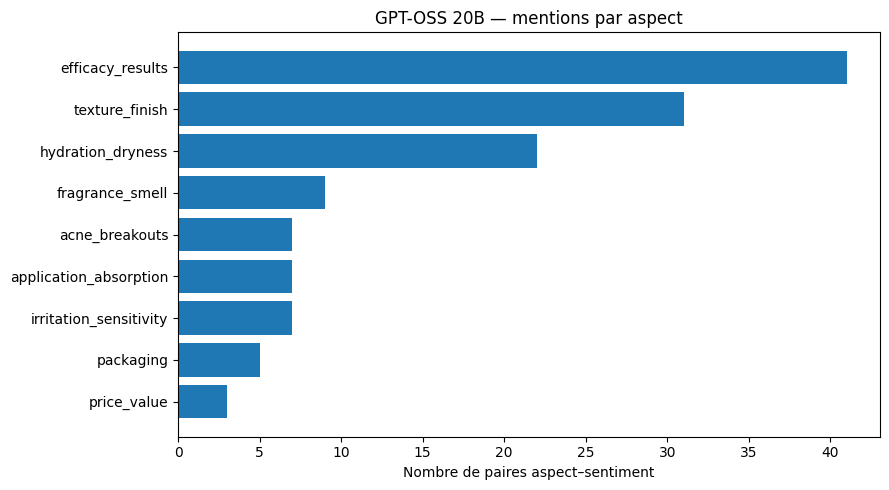


 Llama 3.1 8B


,n_pairs
aspect_id,
efficacy_results,57
texture_finish,30
hydration_dryness,28
price_value,25
application_absorption,22
acne_breakouts,13
irritation_sensitivity,9
fragrance_smell,8
packaging,5


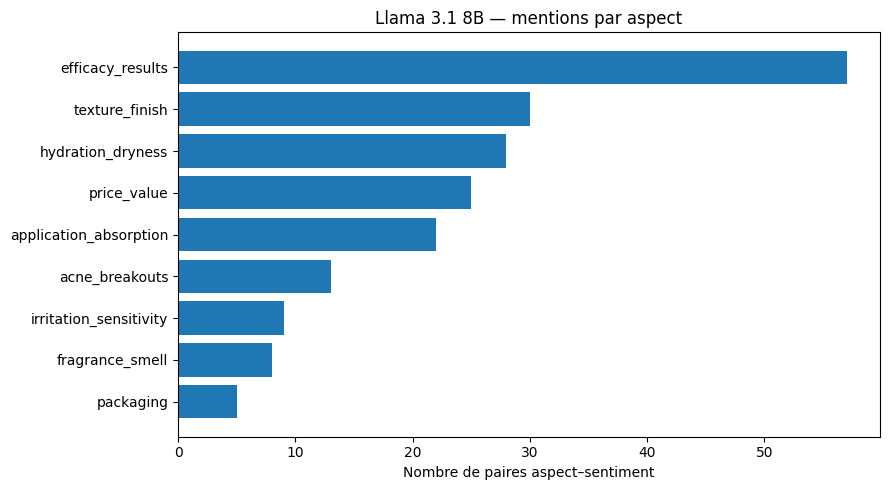

In [20]:
models = {
    "GPT-OSS 20B": results["gpt_oss_20b"]["pairs"],
    "Llama 3.1 8B": results["llama-3.1-8b-instruct"]["pairs"],
}

for model_name, pairs_model in models.items():

    if len(pairs_model):
        aspect_counts = (
            pairs_model["aspect_id"]
            .value_counts()
            .sort_values()
        )

        print("\n", model_name)
        display(
            aspect_counts
            .sort_values(ascending=False)
            .to_frame("n_pairs")
        )

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(aspect_counts.index, aspect_counts.values)
        ax.set_title(f"{model_name} — mentions par aspect")
        ax.set_xlabel("Nombre de paires aspect–sentiment")
        fig.tight_layout()
        plt.show()

    else:
        print(f"{model_name}: aucune paire retournée.")

## 6. Sentiments prédits


 GPT-OSS 20B


,count
sentiment,
positive,107
negative,21
neutral,4


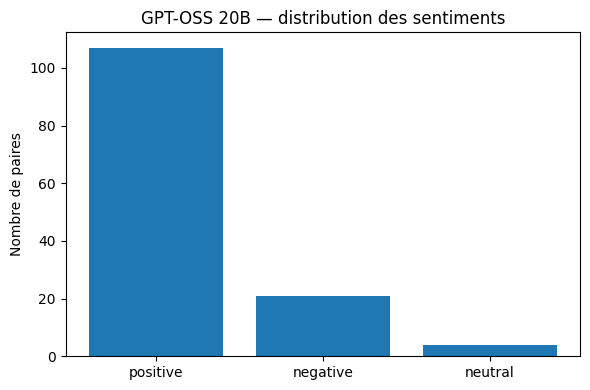


 Llama 3.1 8B


,count
sentiment,
positive,143
negative,37
neutral,17


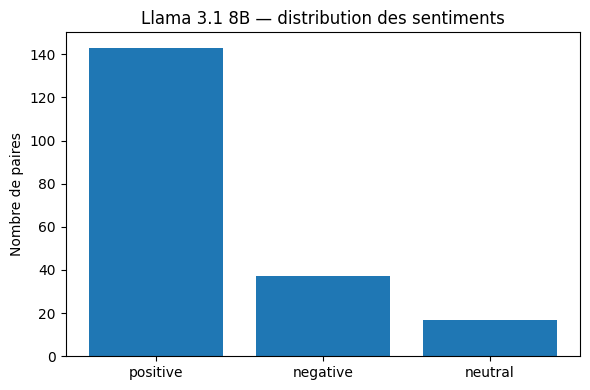

In [19]:
models = {
    "GPT-OSS 20B": results["gpt_oss_20b"]["pairs"],
    "Llama 3.1 8B": results["llama-3.1-8b-instruct"]["pairs"],
}

for model_name, pairs_model in models.items():

    if len(pairs_model):
        sent = pairs_model["sentiment"].value_counts()

        print("\n", model_name)
        display(sent.to_frame("count"))

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(sent.index, sent.values)
        ax.set_title(f"{model_name} — distribution des sentiments")
        ax.set_ylabel("Nombre de paires")
        fig.tight_layout()
        plt.show()